# Objectives

- Explore missing values and potentially problematic features
- Study the relationship between varibles and target
- Identify data quality issues
- Gather information to guide following data cleaning and preprocessing decisions.

# Imports

In [1]:
import pandas as pd
import math
import random
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             mean_absolute_error, mean_squared_error, r2_score)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
import time
import plotly.express as px
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['legend.fontsize'] = 10
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap

# Helper Functions

In [2]:
def separate_columns_by_type(df):

    categorical_cols = []
    numerical_cols = []

    for col in df.columns:
        if col == 'type':
            categorical_cols.append(col)
            continue

        if pd.api.types.is_numeric_dtype(df[col]):
            if pd.api.types.is_integer_dtype(df[col]) and df[col].nunique() < 20:
                categorical_cols.append(col)
            else:
                numerical_cols.append(col)
        else:
            categorical_cols.append(col)

    return categorical_cols, numerical_cols

In [3]:
def analyze_categorical(df, feature, target="readmitted"):
    print(f"\n{'='*60}")
    print(feature)
    print(f"{'='*60}")

    print("\nValue counts:")
    print(df[feature].value_counts(dropna=False))

    print("\nRelationship with target:")
    print(
        pd.crosstab(
            df[feature],
            df[target],
            normalize="index"
        ).mul(100).round(2)
    )

In [4]:
def analyze_numerical(df, feature, target="readmitted"):
    print("=" * 70)
    print(f"Feature: {feature}")
    print("=" * 70)

    display(df.groupby(target)[feature].describe().round(2))

    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x=target, y=feature)
    plt.title(f"{feature} by {target}")
    plt.tight_layout()
    plt.show()

# Load dataset

In [5]:
df = pd.read_csv(r'C:\Users\Usuario\Proyectos\Trabajos\Diabetes readmission prediction\data\Raw/diabetic_data.csv')
print(df.shape)
df.head()

(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [6]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
encounter_id,101766.0,1.652016e+08,1.026403e+08,12522.0,84961194.0,152388987.0,2.302709e+08,443867222.0
patient_nbr,101766.0,5.433040e+07,3.869636e+07,135.0,23413221.0,45505143.0,8.754595e+07,189502619.0
admission_type_id,101766.0,2.024006e+00,1.445403e+00,1.0,1.0,1.0,3.000000e+00,8.0
discharge_disposition_id,101766.0,3.715642e+00,5.280166e+00,1.0,1.0,1.0,4.000000e+00,28.0
admission_source_id,101766.0,5.754437e+00,4.064081e+00,1.0,1.0,7.0,7.000000e+00,25.0
time_in_hospital,101766.0,4.395987e+00,2.985108e+00,1.0,2.0,4.0,6.000000e+00,14.0
num_lab_procedures,101766.0,4.309564e+01,1.967436e+01,1.0,31.0,44.0,5.700000e+01,132.0
num_procedures,101766.0,1.339730e+00,1.705807e+00,0.0,0.0,1.0,2.000000e+00,6.0
num_medications,101766.0,1.602184e+01,8.127566e+00,1.0,10.0,15.0,2.000000e+01,81.0
number_outpatient,101766.0,3.693572e-01,1.267265e+00,0.0,0.0,0.0,0.000000e+00,42.0


# Feature analysis

## Conflictive features

Some features that might need treating.
- **patient_nbr:**  Is a patient ID.
- **weight:**  Presents a high amount of missing values. 
- **race:**  Presents a small amount of missing values (2273 out of 101766)
- **medical_speciality:**  About half of its values are empty. But it is valuable information.
- **payer_code:**  About 40% of values missing, while also not giving essential or easily understandable information for this project.

### patient_nbr

In [7]:
df['patient_nbr'].value_counts()

patient_nbr
88785891     40
43140906     28
1660293      23
23199021     23
88227540     23
             ..
183087545     1
188574944     1
140199494     1
120975314     1
175429310     1
Name: count, Length: 71518, dtype: int64

In [8]:
display(df['number_outpatient'].value_counts())
display(df['number_inpatient'].value_counts())

number_outpatient
0     85027
1      8547
2      3594
3      2042
4      1099
5       533
6       303
7       155
8        98
9        83
10       57
11       42
13       31
12       30
14       28
15       20
16       15
17        8
20        7
21        7
18        5
22        5
19        3
27        3
24        3
35        2
29        2
36        2
26        2
33        2
25        2
23        2
42        1
39        1
34        1
28        1
37        1
38        1
40        1
Name: count, dtype: int64

number_inpatient
0     67630
1     19521
2      7566
3      3411
4      1622
5       812
6       480
7       268
8       151
9       111
10       61
11       49
12       34
13       20
14       10
15        9
16        6
19        2
17        1
21        1
18        1
Name: count, dtype: int64

In [9]:
columns_to_show = [
    "patient_nbr",
    "encounter_id",
    "readmitted",
    "number_outpatient",
    "number_inpatient",
    "number_emergency",
    "time_in_hospital"
]

df.loc[df["patient_nbr"] == 88785891, columns_to_show]

,patient_nbr,encounter_id,readmitted,number_outpatient,number_inpatient,number_emergency,time_in_hospital
38307,88785891,119039172,>30,0,0,0,1
40252,88785891,125094312,<30,1,2,0,1
40661,88785891,126171582,>30,1,3,0,5
44515,88785891,137245596,<30,1,5,0,2
45147,88785891,139425576,<30,1,6,0,2
45986,88785891,141994242,<30,1,7,0,4
50167,88785891,150986298,<30,4,9,1,1
50393,88785891,151413846,<30,4,9,1,4
50773,88785891,152188656,<30,4,10,1,1
51519,88785891,153558456,<30,3,11,1,1


In [10]:
df.loc[df["patient_nbr"] == 43140906, columns_to_show]

,patient_nbr,encounter_id,readmitted,number_outpatient,number_inpatient,number_emergency,time_in_hospital
40232,43140906,125048580,<30,0,0,0,4
40805,43140906,126574968,<30,1,1,0,1
41140,43140906,127455774,<30,1,2,1,2
41560,43140906,128462484,>30,1,3,1,3
44802,43140906,138303666,>30,1,5,2,2
54281,43140906,158221548,>30,1,6,3,1
70538,43140906,202607562,<30,0,1,1,2
70881,43140906,204233946,<30,0,2,1,3
71226,43140906,205970568,<30,0,2,0,2
71730,43140906,208582026,<30,0,3,0,3


** Conclusions **

I wanted to make sure patient_nbr isn´t just an ID, since there´s values indicating one patient appears multiple times in the dataset, 
it could potentially be useful information how many times a patient has needed a hospital visit to predict readmission.
Nonetheless, after doing a quick check using a few individuals as an example, looking the values in number_inpatient and outpatient visits 
and emergency visits, their values seems to be elevated the more a patient is repeated in the dataset.
Of course, the combined emergency, outpatient and inpatient visits don´t add up to the total patient´s entire history in the dataset,
which is logic since those 3 visits are values counted based on visits made one year prior to the entry.
I can only theorize this means the variables are consistent with their documented definition in the source material.

### Medical_speciality

In [11]:
display(df["medical_specialty"].describe())
display(df["medical_specialty"].nunique())
display(df["medical_specialty"].value_counts().head(20))

count     101766
unique        73
top            ?
freq       49949
Name: medical_specialty, dtype: object

73

medical_specialty
?                                    49949
InternalMedicine                     14635
Emergency/Trauma                      7565
Family/GeneralPractice                7440
Cardiology                            5352
Surgery-General                       3099
Nephrology                            1613
Orthopedics                           1400
Orthopedics-Reconstructive            1233
Radiologist                           1140
Pulmonology                            871
Psychiatry                             854
Urology                                685
ObstetricsandGynecology                671
Surgery-Cardiovascular/Thoracic        652
Gastroenterology                       564
Surgery-Vascular                       533
Surgery-Neuro                          468
PhysicalMedicineandRehabilitation      391
Oncology                               348
Name: count, dtype: int64

In [12]:
missing_pct = (df["medical_specialty"] == "?").mean() * 100
print(f"Missing values: {missing_pct:.2f}%")

Missing values: 49.08%


In [13]:
df["medical_specialty_missing"] = df["medical_specialty"] == "?"

pd.crosstab(
    df["medical_specialty_missing"],
    df["readmitted"],
    normalize="index"
)

readmitted,<30,>30,NO
medical_specialty_missing,,,
False,0.107609,0.334427,0.557964
True,0.115738,0.364692,0.519570


In [14]:
pd.crosstab(
    df["medical_specialty"],
    df["readmitted"],
    normalize="index"
)

readmitted,<30,>30,NO
medical_specialty,,,
?,0.115738,0.364692,0.519570
AllergyandImmunology,0.428571,0.428571,0.142857
Anesthesiology,0.083333,0.250000,0.666667
Anesthesiology-Pediatric,0.052632,0.263158,0.684211
Cardiology,0.079410,0.346226,0.574365
...,...,...,...
Surgery-PlasticwithinHeadandNeck,0.000000,1.000000,0.000000
Surgery-Thoracic,0.100917,0.275229,0.623853
Surgery-Vascular,0.138837,0.375235,0.485929


**Conclusions** 

This feature has 49% missing values, but there are variations in the readmission rates across specialities. 
Despite the missingness, the variable may contain useful information, and will be further evaluated in the data cleaning stage.

### Race

In [15]:
display(df["race"].describe())
display(df["race"].nunique())
display(df["race"].value_counts().head(20))

count        101766
unique            6
top       Caucasian
freq          76099
Name: race, dtype: object

6

race
Caucasian          76099
AfricanAmerican    19210
?                   2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

In [16]:
pd.crosstab(
    df["race"],
    df["readmitted"],
    normalize="index"
)

readmitted,<30,>30,NO
race,,,
?,0.082710,0.236692,0.680598
AfricanAmerican,0.112181,0.345341,0.542478
Asian,0.101404,0.251170,0.647426
Caucasian,0.112906,0.356430,0.530664
Hispanic,0.104075,0.315169,0.580756
Other,0.096282,0.296149,0.607570


In [17]:
missing_pc = (df["race"] == "?").mean() * 100
print(f"Missing values: {missing_pc:.2f}%")

Missing values: 2.23%


**Conclusions**

Racial distribution is inbalanced, with a majority of caucasian patients. 
With only ~2% of missing values, this feature can be retained with appropiate imputation during data cleaning.
Whether to combine the less frequent categories into one is to be adressed.

### weight

In [18]:
display(df["weight"].describe())
display(df["weight"].nunique())
display(df["weight"].value_counts().head(20))

count     101766
unique        10
top            ?
freq       98569
Name: weight, dtype: object

10

weight
?            98569
[75-100)      1336
[50-75)        897
[100-125)      625
[125-150)      145
[25-50)         97
[0-25)          48
[150-175)       35
[175-200)       11
>200             3
Name: count, dtype: int64

In [19]:
missing_we = (df["weight"] == "?").mean() * 100
print(f"Missing values: {missing_we:.2f}%")

Missing values: 96.86%


**Conclusions**

With +95% missing values, there´s no reason to keep this feature in the dataset. 
Also, with the exceptions for patients between 0-25 pounds, all other categories of weight don´t show an obvious tendency
in their relation to readmission.

### A1Cresult

In [20]:
df["A1Cresult"].isna().mean() * 100

np.float64(83.27732248491637)

In [21]:
pd.crosstab(
    df["A1Cresult"],
    df["readmitted"],
    normalize="index"
)

readmitted,<30,>30,NO
A1Cresult,,,
>7,0.100472,0.341028,0.558499
>8,0.098710,0.353092,0.548199
Norm,0.096593,0.320441,0.582966


In [22]:
df["A1C_test_performed"] = df["A1Cresult"].notna()

pd.crosstab(
    df["A1C_test_performed"],
    df["readmitted"],
    normalize="index"
).mul(100).round(2)

readmitted,<30,>30,NO
A1C_test_performed,,,
False,11.42,35.10,53.48
True,9.85,34.08,56.07


**Conclusions**

A1Cresult is clinically meaningful, but there´s a high proportion of missing values (~83%).
Results above show a modest 3% difference in readmission rates between patients who had the test performed and patients who didn´t. 

There´s also a ~4% difference in readmission rates between patients with >7 and >8 values, and patients on normal values (with the latter having less readmission rate) 

The feature should be further evaluated during data cleaning.

### max_glu_serum

In [23]:
df["max_glu_serum"].isna().mean() * 100

np.float64(94.74677200636755)

In [24]:
pd.crosstab(
    df["max_glu_serum"],
    df["readmitted"],
    normalize="index"
)

readmitted,<30,>30,NO
max_glu_serum,,,
>200,0.124579,0.356902,0.518519
>300,0.143196,0.412184,0.444620
Norm,0.113593,0.340778,0.545630


In [25]:
df["maxglu_performed"] = df["max_glu_serum"].notna()

pd.crosstab(
    df["maxglu_performed"],
    df["readmitted"],
    normalize="index"
).mul(100).round(2)

readmitted,<30,>30,NO
maxglu_performed,,,
False,11.09,34.86,54.05
True,12.36,36.21,51.42


**Conclusions**

About 95% of values have no record of glucose measurement.

Among patients with available results, the readmission rate increases with higher serum glucose levels.

Patients with the glucose serum test performed to them exhibit a slightly (~3%) higher readmission test compared to those with no test performed.

Despite its high proportion of missing values, max_glu_serum shows one of the clearest relationships with target seen until now in this exploratory analysis. The feature may contain useful predictive value, but its practical usefulness will depend on how missing values are handled.

### payer_code

In [26]:
display(df["payer_code"].describe())
display(df["payer_code"].nunique())
display(df["payer_code"].value_counts().head(20))

count     101766
unique        18
top            ?
freq       40256
Name: payer_code, dtype: object

18

payer_code
?     40256
MC    32439
HM     6274
SP     5007
BC     4655
MD     3532
CP     2533
UN     2448
CM     1937
OG     1033
PO      592
DM      549
CH      146
WC      135
OT       95
MP       79
SI       55
FR        1
Name: count, dtype: int64

In [27]:
pd.crosstab(
    df["payer_code"],
    df["readmitted"],
    normalize="index"
)

readmitted,<30,>30,NO
payer_code,,,
?,0.114939,0.343502,0.541559
BC,0.091515,0.279484,0.629001
CH,0.089041,0.226027,0.684932
CM,0.102220,0.341249,0.556531
CP,0.084485,0.308330,0.607185
DM,0.116576,0.400729,0.482696
FR,0.000000,0.000000,1.000000
HM,0.102646,0.369780,0.527574
MC,0.117451,0.369370,0.513179


In [28]:
missing_pc = (df["payer_code"] == "?").mean() * 100
print(f"Missing values: {missing_pc:.2f}%")

Missing values: 39.56%


**Conclusions**

payer_code has almost 40% missing values.
Abbreviated categories represent different payer types, which without domain knowledge can be difficult to interpret.
Comparing with readmission rate, there is a slight difference between each payer_code category, with no strong or immediately apparent 
relationship noticed without further analyzing.
payer_code is the only variable indirectly related to socioeconomic status, which could contain useful information. 
Its high proportion of missing values and difficult interpretability reduce this feature´s practical value for this project.

## Predictive relationships

After adressing data quality of some variables with missing values, this section is meant to explore other features 
and study if they could help explain the target.

### Categorical features

In [29]:
categorical = [
    "age",
    "race",
    "admission_type_id",
    "medical_specialty",
    "change"
]

for feature in categorical:
    analyze_categorical(df, feature)


age

Value counts:
age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

Relationship with target:
readmitted    <30    >30     NO
age                            
[0-10)       1.86  16.15  81.99
[10-20)      5.79  32.42  61.79
[20-30)     14.24  30.78  54.98
[30-40)     11.23  31.44  57.32
[40-50)     10.60  33.85  55.55
[50-60)      9.67  34.29  56.04
[60-70)     11.13  35.12  53.75
[70-80)     11.77  36.35  51.88
[80-90)     12.08  36.19  51.73
[90-100)    11.10  28.93  59.97

race

Value counts:
race
Caucasian          76099
AfricanAmerican    19210
?                   2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

Relationship with target:
readmitted         <30    >30     NO
race                                
?                 8.27  23.67  68.06
AfricanAmerican  11

**Conclusions** 

- Most categorical variables exhibit inbalanced class distributions, with a few categories accounting for the majority of observations
- No single category shows strong or immediately apparent association with the readmission rate. Noteable exception: class age 0-10, showing substantially higher proportion of patients with no readmission.
- While no individual category is a strong predictors on their own, they could still contribute useful information alongside other variables in the predictive model

### Numerical features

Feature: number_diagnoses


,count,mean,std,min,25%,50%,75%,max
readmitted,,,,,,,,
<30,11357.0,7.69,1.77,1.0,6.0,9.0,9.0,16.0
>30,35545.0,7.65,1.81,1.0,6.0,9.0,9.0,16.0
NO,54864.0,7.22,2.02,1.0,6.0,8.0,9.0,16.0


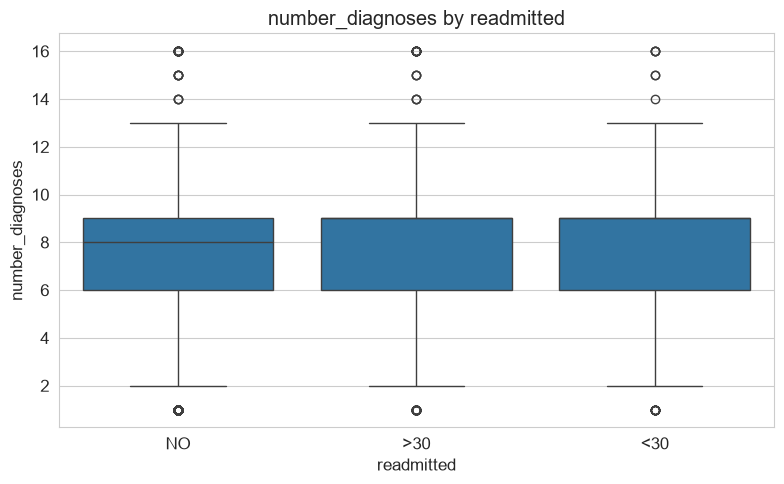

Feature: time_in_hospital


,count,mean,std,min,25%,50%,75%,max
readmitted,,,,,,,,
<30,11357.0,4.77,3.03,1.0,2.0,4.0,6.0,14.0
>30,35545.0,4.50,2.99,1.0,2.0,4.0,6.0,14.0
NO,54864.0,4.25,2.96,1.0,2.0,3.0,6.0,14.0


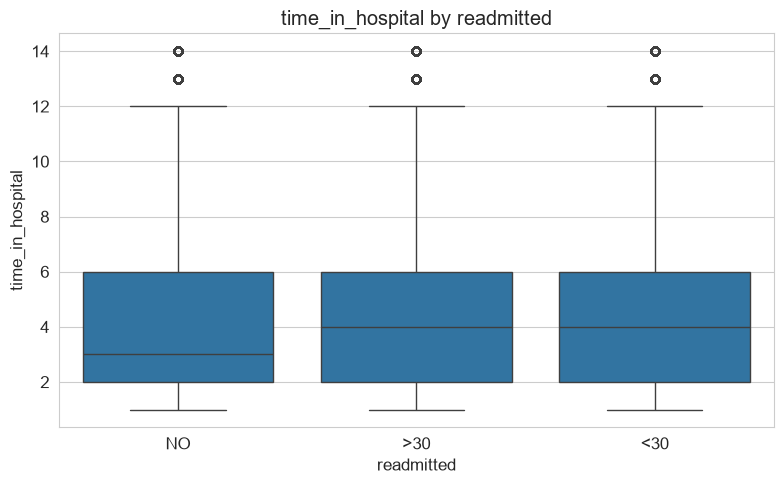

Feature: num_medications


,count,mean,std,min,25%,50%,75%,max
readmitted,,,,,,,,
<30,11357.0,16.90,8.10,1.0,11.0,16.0,21.0,81.0
>30,35545.0,16.28,7.62,1.0,11.0,15.0,20.0,70.0
NO,54864.0,15.67,8.43,1.0,10.0,14.0,20.0,79.0


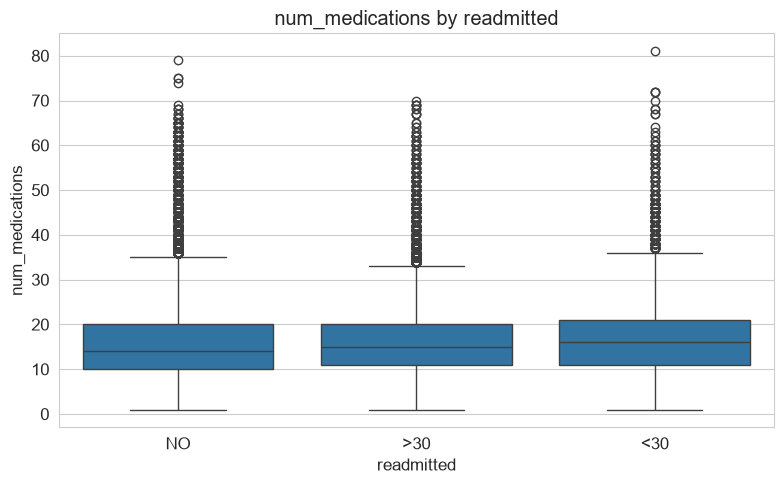

Feature: num_lab_procedures


,count,mean,std,min,25%,50%,75%,max
readmitted,,,,,,,,
<30,11357.0,44.23,19.28,1.0,33.0,45.0,58.0,132.0
>30,35545.0,43.84,19.57,1.0,32.0,45.0,58.0,129.0
NO,54864.0,42.38,19.80,1.0,30.0,44.0,56.0,126.0


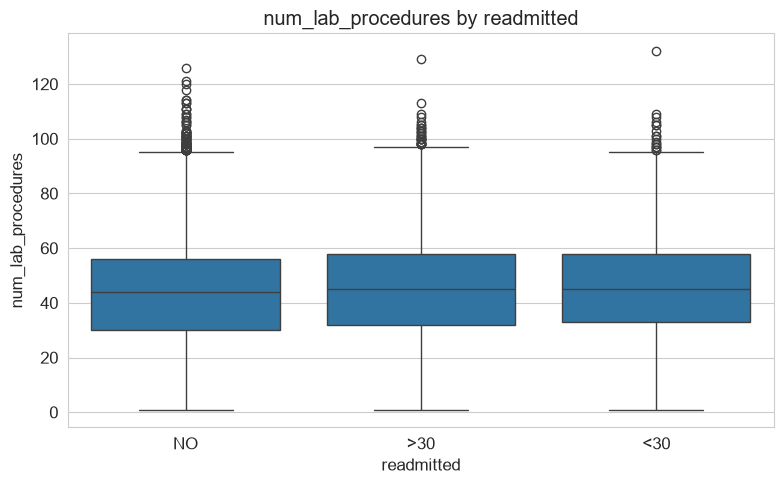

In [30]:
numerical = [
    "number_diagnoses",
    "time_in_hospital",
    "num_medications",
    "num_lab_procedures"
]

for feature in numerical:
    analyze_numerical(df, feature)

**Conclusions**

Numerical variables show overlap between readmission groups, so none of them provide a clear separation of target classes.

A consistent pattern can be seen in several variables, with patients that had no readmission have slightly lower values for days in hospital, number of diagnosis, number of medications and laboratory procedures. 

The relationship is very modest but consistent, suggesting a greater burden of illness and healthcare utilization is associated with an increased likelihood of readmission.

# Overall Conclusions

- *weight* : contains ~95% missing values and is unlikely to be useful
- *payer_code*: high amount of missing values and limited interpretability, candidate for removal
- *medical_speciality*, *A1Cresult* and *max_glu_serum*: all contain an important amount of null values, but they provide useful clinical information.
- *race*: Contains a relatively manageable missingness and can be retained.

- While no single variable show a strong predictive relationship with readmission rate, several features show slight trends. Patients who have been readmitted to the hospital tend to have longer hospital stays, more diagnoses and tests performed, and more medication.
- *max_glu_serum* shows the most promising relationship between its classes and readmission rate, despite its missingness. 

Next notebook will focus on data cleaning and preprocessing. The information obtained in this EDA will guide the following decisions for feature removal/engineering, working around missing values and preprocessing data for modeling. 